# 02 — EDA, Time-Based Validation Split, Metrics & Popularity Baseline

**Purpose:** build the *ruler* before building any model.

1. EDA (one finding per cell) — date range, sparsity, repurchase rate, top-seller
   concentration, price outliers, cold users/items.
2. A **time-based** validation split (never random — that leaks the future).
3. The MAP@12 / NDCG@12 metrics, unit-tested on a tiny example.
4. A **popularity baseline** MAP@12 — the number every later stage must beat.

In [1]:
from recsys_utils import *
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
mlflow = setup_mlflow()

articles     = load_parquet(PROCESSED_DIR / 'articles_clean.parquet')
customers    = load_parquet(PROCESSED_DIR / 'customers_clean.parquet')
transactions = load_parquet(PROCESSED_DIR / 'transactions_clean.parquet')
print('transactions', transactions.shape)

transactions (31788324, 5)


## EDA

In [2]:
# Volume & date range
print('Unique customers :', transactions['customer_id'].nunique())
print('Unique articles  :', transactions['article_id'].nunique())
print('Date range       :', transactions['t_dat'].min().date(), 'to', transactions['t_dat'].max().date())
print('Total purchases  :', len(transactions))

Unique customers : 1362281
Unique articles  : 104547
Date range       : 2018-09-20 to 2020-09-22
Total purchases  : 31788324


In [3]:
# Sparsity: how much history does the average user / item have?
per_cust = transactions.groupby('customer_id').size()
per_art  = transactions.groupby('article_id').size()
print('Purchases per customer:'); print(per_cust.describe(), '\n')
print('Purchases per article :'); print(per_art.describe())

Purchases per customer:
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
dtype: float64 

Purchases per article :
count    104547.000000
mean        304.057735
std         791.266060
min           1.000000
25%          14.000000
50%          65.000000
75%         286.000000
max       50287.000000
dtype: float64


In [4]:
# Repurchase rate: fraction of purchases that repeat a (customer, article) pair.
# Drives how strong the 'repurchase' candidate source will be.
dup = transactions.duplicated(subset=['customer_id', 'article_id']).mean()
print(f'{dup:.1%} of purchases are repeats of an article the customer already bought')

14.1% of purchases are repeats of an article the customer already bought


In [5]:
# Top-seller concentration: do a few items dominate sales? (popularity baseline strength)
vc = transactions['article_id'].value_counts()
for n in (100, 1000):
    print(f'Top {n:>4} items account for {vc.head(n).sum()/len(transactions):.1%} of all purchases')

Top  100 items account for 4.6% of all purchases
Top 1000 items account for 18.2% of all purchases


count    3.178832e+07
mean     2.782927e-02
std      1.833236e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64


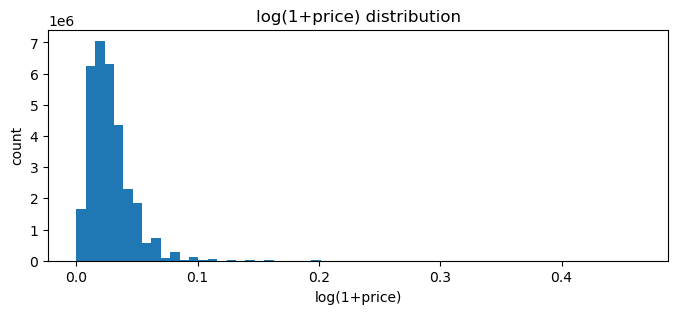

In [6]:
# Price distribution & outliers
print(transactions['price'].describe())
plt.figure(figsize=(8,3))
plt.hist(np.log1p(transactions['price'].values), bins=60)
plt.title('log(1+price) distribution'); plt.xlabel('log(1+price)'); plt.ylabel('count'); plt.show()

In [7]:
# Cold users / items (the hard cases the model will struggle with)
print(f'Customers with exactly 1 purchase: {(per_cust == 1).sum():,} ({(per_cust==1).mean():.1%})')
print(f'Articles  with <= 1 purchase     : {(per_art <= 1).sum():,} ({(per_art<=1).mean():.1%})')

Customers with exactly 1 purchase: 131,514 (9.7%)
Articles  with <= 1 purchase     : 4,491 (4.3%)


## Validation scheme (time-based, two cutoffs)

We never use a random split — that lets the model train on a December purchase and validate
on a November one (leakage). Instead we split by time, and we use **two** 7-day windows so the
ranker is trained and evaluated on *different* weeks:

```
        ... history ...   | TRAIN week (7d) |  VAL week (7d) = holdout
  build train candidates  ^                                          
  & features from here ----+ (t_dat < train_week_start)              
  build val candidates -------------------+ (t_dat < val_week_start) 
```

- **VAL week** = last 7 days. We predict it using only data *before* it. This is the score that matters.
- **TRAIN week** = the 7 days before that. The ranker learns its labels here, using only data before *it*.

Training the ranker and scoring it on the same week would be leakage, so we keep them separate.

In [8]:
last_day         = transactions['t_dat'].max().normalize()
val_week_start   = last_day - pd.Timedelta(days=VAL_DAYS - 1)        # 7-day VAL window
train_week_end   = val_week_start - pd.Timedelta(days=1)
train_week_start = train_week_end - pd.Timedelta(days=VAL_DAYS - 1)  # 7-day TRAIN window

split_config = {
    'val_week_start':   str(val_week_start.date()),   'val_week_end':   str(last_day.date()),
    'train_week_start': str(train_week_start.date()), 'train_week_end': str(train_week_end.date()),
    # features/candidates for each week use only data strictly before its start:
    'val_basis_end_exclusive':   str(val_week_start.date()),
    'train_basis_end_exclusive': str(train_week_start.date()),
}
save_json(split_config, PROCESSED_DIR / 'split_config.json')
for k, v in split_config.items():
    print(f'{k:28s}: {v}')

Saved: C:\Users\Michael Fulling\H&M Project\data\processed\split_config.json
val_week_start              : 2020-09-16
val_week_end                : 2020-09-22
train_week_start            : 2020-09-09
train_week_end              : 2020-09-15
val_basis_end_exclusive     : 2020-09-16
train_basis_end_exclusive   : 2020-09-09


In [9]:
# Ground-truth tables: what each customer actually bought in each label week.
def truth_table(df, start, end):
    m = (df['t_dat'] >= start) & (df['t_dat'] <= end)
    return (df.loc[m].groupby('customer_id')['article_id']
              .apply(lambda s: list(dict.fromkeys(s)))  # de-dup, keep order
              .rename('actual').reset_index())

val_truth   = truth_table(transactions, val_week_start, last_day)
train_truth = truth_table(transactions, train_week_start, train_week_end)
save_parquet(val_truth,   PROCESSED_DIR / 'val_truth.parquet')
save_parquet(train_truth, PROCESSED_DIR / 'train_truth.parquet')
print('Customers with a VAL-week purchase  :', len(val_truth))
print('Customers with a TRAIN-week purchase:', len(train_truth))

Saved: C:\Users\Michael Fulling\H&M Project\data\processed\val_truth.parquet  shape=(68984, 2)
Saved: C:\Users\Michael Fulling\H&M Project\data\processed\train_truth.parquet  shape=(72019, 2)
Customers with a VAL-week purchase  : 68984
Customers with a TRAIN-week purchase: 72019


## Metrics (unit-tested)

In [10]:
# Tiny hand-checked example. Actual = {A, C}. Prediction ranks A first (rank1) and C fourth.
#   hit at rank1 -> precision 1/1 = 1.0 ; hit at rank4 -> precision 2/4 = 0.5
#   AP@12 = (1.0 + 0.5) / min(2, 12) = 0.75
ap = apk(['A', 'C'], ['A', 'X', 'Y', 'C'], k=12)
print('AP@12 =', round(ap, 4))
assert abs(ap - 0.75) < 1e-9, ap
assert apk([], ['A'], 12) == 0.0
print('MAP@12 metric verified.')

AP@12 = 0.75
MAP@12 metric verified.


## Popularity baseline — the number to beat

In [11]:
# Most-purchased items in the 14 days before the VAL week (recency matters in fashion).
POP_DAYS = 14
val_basis = transactions[transactions['t_dat'] < val_week_start]
pop_window = val_basis[val_basis['t_dat'] >= val_week_start - pd.Timedelta(days=POP_DAYS)]
top12 = pop_window['article_id'].value_counts().head(TOP_K).index.tolist()
print('Top-12 popular article ids:', [format_article_id(a) for a in top12])

actuals = val_truth['actual'].tolist()
preds   = [top12] * len(actuals)               # recommend the same 12 to everyone
base_map  = mapk(actuals, preds, TOP_K)
base_ndcg = mean_ndcg(actuals, preds, TOP_K)
print(f'\nPOPULARITY BASELINE   MAP@12 = {base_map:.5f}   NDCG@12 = {base_ndcg:.5f}')
print('Every later stage (ALS, ranker) must beat this MAP@12.')

Top-12 popular article ids: ['0751471001', '0909370001', '0915526001', '0751471043', '0448509014', '0706016001', '0918292001', '0918522001', '0915529003', '0896152002', '0863595006', '0865799006']

POPULARITY BASELINE   MAP@12 = 0.00710   NDCG@12 = 0.01405
Every later stage (ALS, ranker) must beat this MAP@12.


In [12]:
with mlflow.start_run(run_name='02_baseline_popularity'):
    mlflow.log_param('pop_days', POP_DAYS)
    mlflow.log_param('val_week_start', split_config['val_week_start'])
    mlflow.log_metric('baseline_map_at_12', base_map)
    mlflow.log_metric('baseline_ndcg_at_12', base_ndcg)
    mlflow.log_metric('val_customers', len(val_truth))
print('Logged baseline to MLflow.')

2026/06/11 12:07:31 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Logged baseline to MLflow.
